In [72]:
library(dplyr)
library(stringr)

In [73]:
library(tidyr)

In [74]:
library(ggpubr)

In [75]:
library(ggplot2)

In [76]:
phe <- read.table("phe_plusTF_footprint.txt",header=T,sep='\t')

In [77]:
rownames(phe) <- phe$name

In [78]:
All_anno <- readRDS("All_pair_anno.Rdata")

In [79]:
C2_anno <- readRDS("C2_pair_anno.Rdata")

In [80]:
C3_anno <- readRDS("C3_pair_anno.Rdata")

In [81]:
All_states <- read.table("All_bins_sample.states",header=T)

In [82]:
phe %>% filter(footprint=='C2') %>% rownames() -> C2names
phe %>% filter(footprint=='C3') %>% rownames() -> C3names

### find the chroamtin states for each peak in the pair-interactions

In [83]:
C2_anno %>% mutate(Promoter_index = ifelse(abs(Dis_L)>abs(Dis_R),index2,index1)) -> C2_anno
C2_anno %>% mutate(Enhancer_index = ifelse(abs(Dis_L)>abs(Dis_R),index1,index2)) -> C2_anno

In [84]:
C3_anno %>% mutate(Promoter_index = ifelse(abs(Dis_L)>abs(Dis_R),index2,index1)) -> C3_anno
C3_anno %>% mutate(Enhancer_index = ifelse(abs(Dis_L)>abs(Dis_R),index1,index2)) -> C3_anno

In [85]:
All_anno %>% mutate(Promoter_index = ifelse(abs(Dis_L)>abs(Dis_R),index2,index1)) -> All_anno
All_anno %>% mutate(Enhancer_index = ifelse(abs(Dis_L)>abs(Dis_R),index1,index2)) -> All_anno

In [87]:
C2_states_Pro <- All_states[C2_anno$Promoter_index,c(C2names,C3names)] 
C2_states_Enh <- All_states[C2_anno$Enhancer_index,c(C2names,C3names)] 

In [88]:
C3_states_Pro <- All_states[C3_anno$Promoter_index,c(C2names,C3names)] 
C3_states_Enh <- All_states[C3_anno$Enhancer_index,c(C2names,C3names)] 

In [89]:
All_anno$Promoter_index  %>% head()

[1] "chr1_958881_959596"   "chr1_960434_960868"   "chr1_999614_1001015" 
[4] "chr1_999614_1001015"  "chr1_1001771_1002102" "chr1_1273373_1274422"

In [91]:
All_states_Pro <- All_states[All_anno$Promoter_index,c(C2names,C3names)] 
All_states_Enh <- All_states[All_anno$Enhancer_index,c(C2names,C3names)] 

### show the distribution by bar plot

In [92]:
names <- c("ActiveTSS","TssFlank","TssFlankD","TxFlank",
           "EnhA1", "EnhA2","EnhPoised1","EnhPrimed",
           "EnhPoised2","EnhBivalent","ReprPC", 
           "Low1","Low2","Low3","Low4")

In [93]:
color <- c("#a50026","#d73027","#f46d43","#fdae61",
           "#fee08b","#ffffbf","#d9ef8b", "#a6d96a",
           "#66bd63","#1a9850","#1886a0",
           "#dbdddc","#bbbcbb","#8e8e8e","#727272",
          "#bdbdbd","#969696")

In [94]:
stat_bar <- function(states_each, group){
    frequency <- lapply(states_each, table)
    result <- as.data.frame(matrix(data = 0,nrow = 15,ncol = 38))
    rownames(result) <- names
    colnames(result) <- colnames(states_each)
    for(each in names(frequency)){
        temp = frequency[each][[1]]
        result[names(temp),each] <- temp
    }
    if(group=="C2"){
        result2 = result[,C2names]
    }else if(group=="C3"){
        result2 = result[,C3names]
    }else{
        result2 = result
    }
    result2$states <- rownames(result)
    result3 <- pivot_longer(data =result2,!states, names_to = "sample", values_to = "Proportion" )
    
    if(group=="C2"){
        result3$Proportion <- result3$Proportion/nrow(states_each[,C2names])
        result3$sample <- factor(result3$sample,levels = c(C2names))
    }else if(group=="C3"){
        result3$Proportion <- result3$Proportion/nrow(states_each[,C3names])
        result3$sample <- factor(result3$sample,levels = C3names)
    }else{
        result3$Proportion <- result3$Proportion/nrow(states_each)
        result3$sample <- factor(result3$sample,levels = c(C2names,C3names))
    }           
    result3$states <- factor(result3$states,levels = names)
    
    if(group=="C2"){
        groupbased <- data.frame(C2 = result[,C2names]  %>% rowMeans())
        groupbased$states <- rownames(groupbased)
        groupbased$C2 <- round(groupbased$C2/nrow(states_each),4)
        
        
    }else if(group=="C3"){
        groupbased <- data.frame(C3 = result[,C3names]  %>% rowMeans())
        groupbased$states <- rownames(groupbased)
        groupbased$C3 <- round(groupbased$C3/nrow(states_each),4)
    }else{
        groupbased <- data.frame(All = result[,c(C2names,C3names)]  %>% rowMeans())
        groupbased$states <- rownames(groupbased)
        groupbased$All <- round(groupbased$All/nrow(states_each),4)
    }
    groupbased <- pivot_longer(data =groupbased,!states, names_to = "sample", values_to = "Proportion" )
    
    groupbased$Proportion <- groupbased$Proportion
    groupbased$states <- factor(groupbased$states,levels = names)
    if(group=="C2"){
        groupbased$group = "C2"
    }else if(group=="C3"){
        groupbased$group = "C3"
    }else{
        groupbased$group = "All"
    }
    ### samples based
    bar_allsample <- ggplot(data = result3,aes(x=sample,y=Proportion,fill=states))+
    geom_bar(stat="identity") +theme_bw() +xlab("") +theme(axis.text = element_text(color="black",size=10))+
    scale_fill_manual(values =c("#a50026","#d73027","#f46d43","#fdae61","#fee08b","#ffffbf","#d9ef8b",
                                "#a6d96a","#66bd63","#1a9850","#1886a0","#dbdddc","#bbbcbb","#8e8e8e",
                               "#727272"))+theme(axis.text.x = element_text(angle=45,hjust = 1))
    ### group based
  #  bar_group <- ggplot(data = C2_groupbased2,aes(x=sample,y=Proportion,fill=states))+
  #  geom_bar(stat="identity") +theme_bw() +xlab("") +theme(axis.text = element_text(color="black",size=10))+
  #  scale_fill_manual(values =c("#a50026","#d73027","#f46d43","#fdae61","#fee08b","#ffffbf","#d9ef8b",
  #                              "#a6d96a","#66bd63","#1a9850","#1886a0","#dbdddc","#bbbcbb","#8e8e8e",
  #                             "#727272"))+theme(axis.text.x = element_text(angle=45,hjust = 1))
    return(list(barsample=bar_allsample,groupbased=groupbased,rlt=result3))
}

In [95]:
barlist_C2 <- stat_bar(rbind(C2_states_Pro,C2_states_Enh),'C2')

In [96]:
barlist_C3 <- stat_bar(rbind(C3_states_Pro,C3_states_Enh),'C3')

In [97]:
barlist_all <- stat_bar(rbind(All_states_Pro,All_states_Enh),'All')

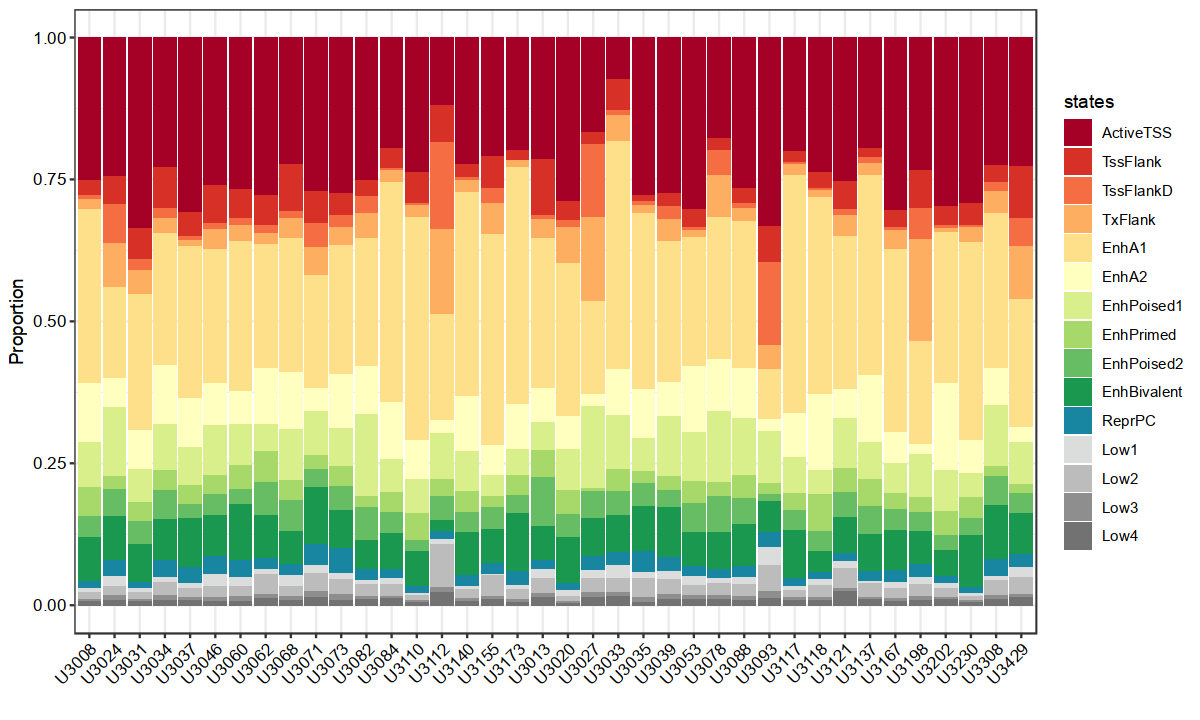

In [98]:
options(repr.plot.height=6,repr.plot.width=10)
barlist_all$barsample

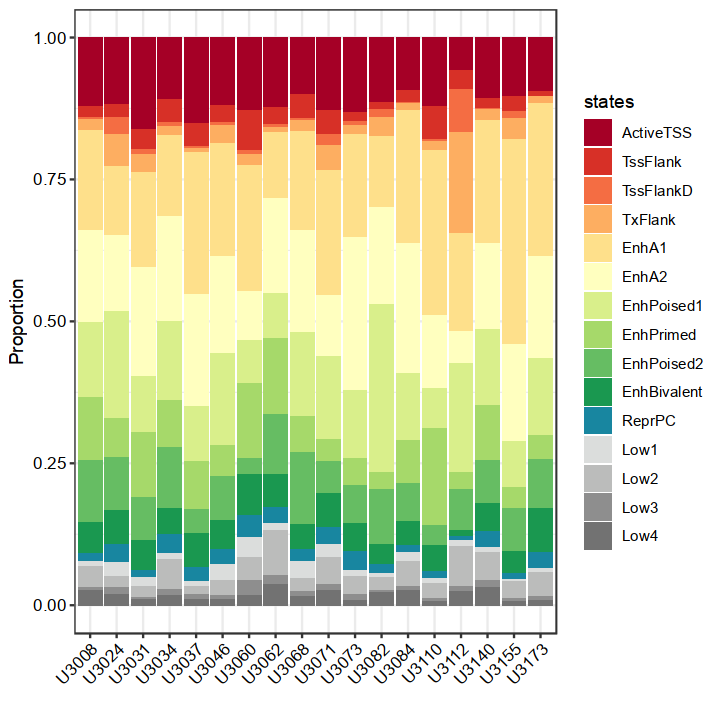

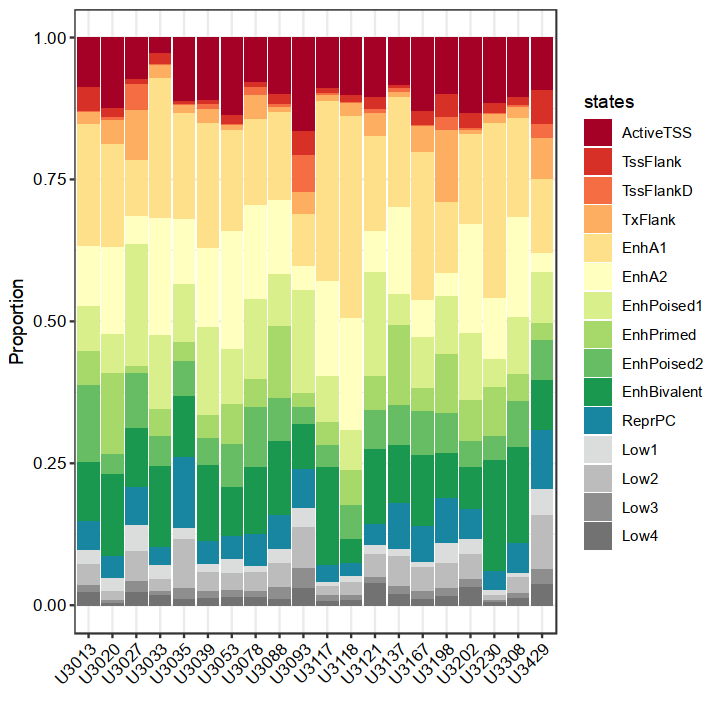

In [99]:
options(repr.plot.height=6,repr.plot.width=6)
barlist_C2$barsample
barlist_C3$barsample

In [100]:
ggsave(filename ="C2_peakstates_proportion_barplot.pdf" ,plot =barlist_C2$barsample ,width =6 ,height = 6)
ggsave(filename ="C3_peakstates_proportion_barplot.pdf" ,plot =barlist_C3$barsample ,width =6 ,height = 6)
ggsave(filename ="All_peakstates_proportion_barplot.pdf" ,plot =barlist_all$barsample ,width =10 ,height = 6)

In [101]:
group_proportion <- rbind(barlist_C2$groupbased,barlist_C3$groupbased,barlist_all$groupbased)

In [102]:
bar_group <- ggplot(data = group_proportion,aes(x=sample,y=Proportion,fill=states))+
  geom_bar(stat="identity") +theme_bw() +xlab("") +theme(axis.text = element_text(color="black",size=10))+
  scale_fill_manual(values =c("#a50026","#d73027","#f46d43","#fdae61","#fee08b","#ffffbf","#d9ef8b",
                              "#a6d96a","#66bd63","#1a9850","#1886a0","#dbdddc","#bbbcbb","#8e8e8e",
                             "#727272"))+theme(axis.text.x = element_text(angle=45,hjust = 1))

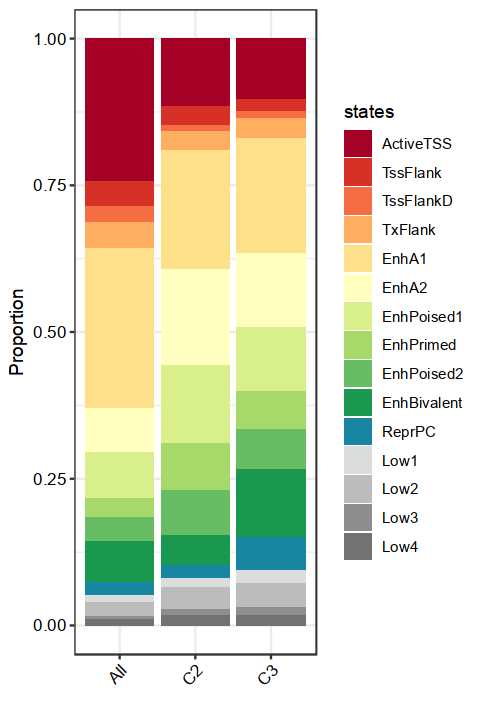

In [103]:
options(repr.plot.height=6,repr.plot.width=4)
bar_group

In [104]:
ggsave(filename ="All_C2_C3_group_peaksstates_proportion_barplot.pdf" ,plot =bar_group ,width =4 ,height = 6)

In [105]:
C2peaks_samples_proportion <- barlist_C2$rlt
C3peaks_samples_proportion <- barlist_C3$rlt
Allpeaks_samples_proportion <- barlist_all$rlt

In [106]:
C2peaks_samples_proportion$group <- "C2"
C3peaks_samples_proportion$group <- "C3"
Allpeaks_samples_proportion$group <- "All"

In [107]:
All_C2_C3_forboxplot <- rbind(C2peaks_samples_proportion,C3peaks_samples_proportion,Allpeaks_samples_proportion)

In [108]:
head(All_C2_C3_forboxplot)

states,sample,Proportion,group
<fct>,<fct>,<dbl>,<chr>
ActiveTSS,U3008,0.1208985,C2
ActiveTSS,U3024,0.1173335,C2
ActiveTSS,U3031,0.1627786,C2
ActiveTSS,U3034,0.1088883,C2
ActiveTSS,U3037,0.1521875,C2
ActiveTSS,U3046,0.1196179,C2


In [110]:
compare_list <- list(c("All","C2"),c("All","C3"),c("C2","C3"))

In [111]:
All_C2_C3_forboxplot$group <- factor(All_C2_C3_forboxplot$group ,levels = c("All","C2","C3"))

In [112]:
p1 <- ggboxplot(All_C2_C3_forboxplot,x="group",y="Proportion",add="jitter",add.params=list(shape=21, fill="orange", size=3)
         )+geom_signif(comparisons = compare_list,step_increase = 0.1,map_signif_level = F,test = t.test
                      )+ scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))+
        ylab("Proportion") + facet_wrap(~states, scale="free")

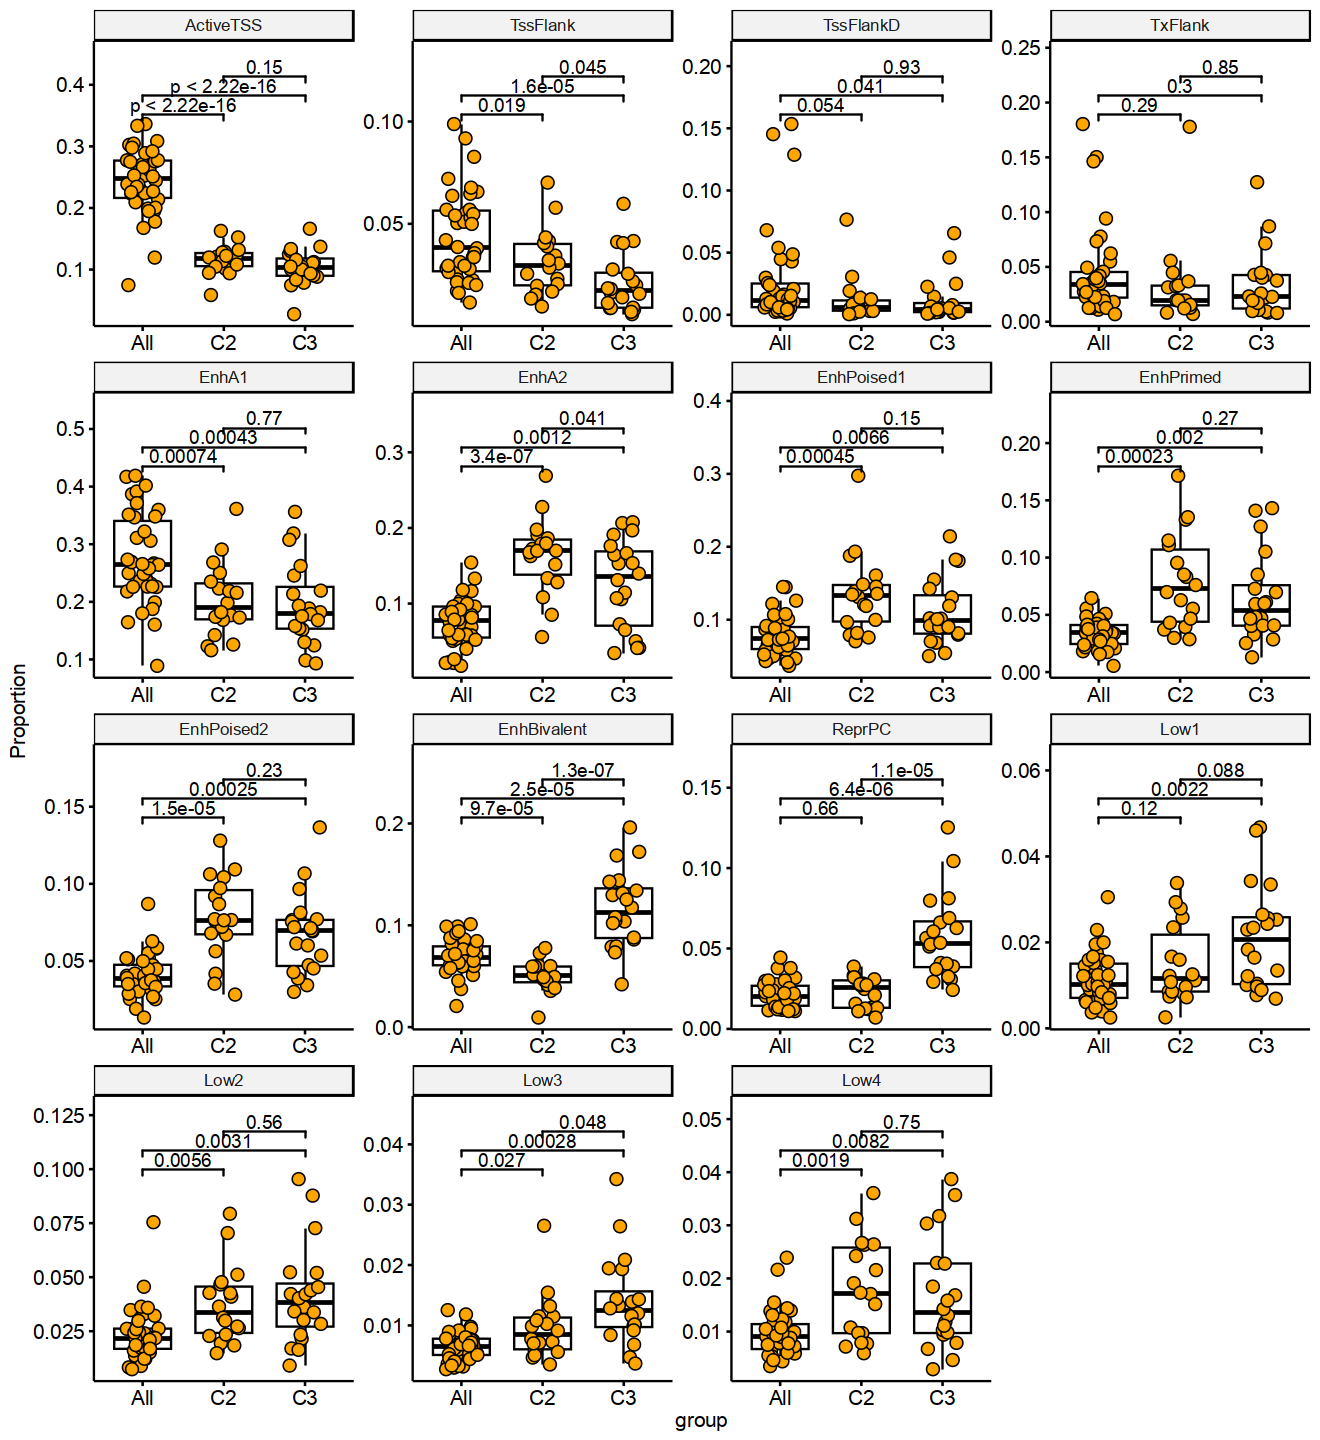

In [113]:
options(repr.plot.height=12,repr.plot.width=11)
p1

In [114]:
ggsave(filename = "All_C2_C3_peaks_compare_boxplot.pdf",plot =p1 ,width =11 ,height =12 )

### combine the pair peaks together

In [115]:
C2_new_df <- data.frame(
  sapply(seq_along(C2_states_Pro), function(i) paste(C2_states_Pro[,i], C2_states_Enh[,i],sep="--"))
)

In [116]:
C3_new_df <- data.frame(
  sapply(seq_along(C3_states_Pro), function(i) paste(C3_states_Pro[,i], C3_states_Enh[,i],sep="--"))
)

In [117]:
All_new_df <- data.frame(
  sapply(seq_along(All_states_Pro), function(i) paste(All_states_Pro[,i], All_states_Enh[,i],sep="--"))
)

In [118]:
colnames(C2_new_df) <- colnames(C2_states_Pro)
colnames(C3_new_df) <- colnames(C3_states_Pro)
colnames(All_new_df) <- colnames(All_states_Pro)

In [119]:
rownames(C2_new_df) <- rownames(C2_anno)
rownames(C3_new_df) <- rownames(C3_anno)
rownames(All_new_df) <- rownames(All_states_Pro)

In [120]:
head(C2_new_df)

,U3008,U3024,U3031,U3034,U3037,U3046,U3060,U3062,U3068,U3071,⋯,U3117,U3118,U3121,U3137,U3167,U3198,U3202,U3230,U3308,U3429
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
ATACpeak_119,ActiveTSS--EnhA1,ActiveTSS--EnhPoised1,ActiveTSS--EnhA1,ActiveTSS--EnhA1,ActiveTSS--EnhA1,ActiveTSS--EnhA1,ActiveTSS--EnhA1,ActiveTSS--EnhPoised1,ActiveTSS--EnhPoised1,ActiveTSS--EnhA1,⋯,EnhA1--EnhPoised2,ActiveTSS--EnhPrimed,ActiveTSS--EnhPoised1,ActiveTSS--EnhA2,ActiveTSS--EnhA1,ActiveTSS--TxFlank,ActiveTSS--EnhA2,ActiveTSS--EnhA1,EnhA1--EnhPoised1,ActiveTSS--EnhA1
ATACpeak_120,EnhA1--EnhA1,EnhPoised1--ActiveTSS,EnhA1--ActiveTSS,EnhA1--EnhA1,EnhA1--ActiveTSS,EnhA1--EnhA1,EnhA1--EnhA1,EnhPoised1--ActiveTSS,EnhPoised1--ActiveTSS,EnhA1--EnhA1,⋯,EnhPoised2--EnhA1,EnhPrimed--ActiveTSS,EnhPoised1--ActiveTSS,EnhA2--ActiveTSS,EnhA1--ActiveTSS,TxFlank--ActiveTSS,EnhA2--ActiveTSS,EnhA1--ActiveTSS,EnhPoised1--EnhA1,EnhA1--TssFlankD
ATACpeak_121,EnhA1--EnhA1,EnhA1--EnhPoised1,EnhA1--EnhA1,EnhA1--EnhA1,EnhA1--EnhA1,EnhA1--EnhA1,EnhA1--EnhA1,EnhA1--EnhPoised1,TxFlank--EnhPoised1,EnhA1--EnhA1,⋯,EnhA1--EnhPoised2,EnhA1--EnhPrimed,EnhA1--EnhPoised1,EnhA1--EnhA2,EnhA1--EnhA1,TxFlank--TxFlank,EnhA1--EnhA2,EnhA1--EnhA1,EnhA1--EnhPoised1,TxFlank--EnhA1
ATACpeak_122,EnhA1--EnhA1,EnhPoised1--TxFlank,EnhA1--EnhA1,EnhA1--EnhA1,EnhA1--EnhA1,EnhA1--EnhPoised1,EnhA1--EnhPoised1,EnhPoised1--EnhPoised1,EnhPoised1--EnhPoised1,EnhA1--EnhA2,⋯,EnhPoised2--TxFlank,EnhPrimed--EnhPrimed,EnhPoised1--EnhA1,EnhA2--EnhA1,EnhA1--EnhA1,TxFlank--TxFlank,EnhA2--EnhPoised1,EnhA1--EnhA1,EnhPoised1--EnhPoised2,EnhA1--TxFlank
ATACpeak_408,ActiveTSS--EnhPrimed,TssFlankD--EnhPoised1,TssFlank--EnhPrimed,ActiveTSS--EnhPoised2,ActiveTSS--TssFlank,TssFlank--EnhA2,TssFlank--TssFlank,TssFlank--EnhPrimed,EnhA1--EnhA2,TssFlank--EnhA1,⋯,TssFlank--EnhPrimed,TssFlank--EnhPrimed,ActiveTSS--EnhA2,TssFlank--Low4,EnhA1--EnhA2,TxFlank--TssFlank,ActiveTSS--EnhPoised2,TssFlank--ActiveTSS,TssFlank--Low4,TssFlank--TssFlank
ATACpeak_713,TxFlank--EnhA2,TxFlank--EnhPoised2,EnhA1--EnhA2,EnhA1--EnhA2,EnhBivalent--EnhA2,EnhBivalent--EnhA2,EnhBivalent--EnhA2,EnhBivalent--EnhPrimed,EnhA1--EnhA2,EnhBivalent--EnhA2,⋯,EnhA1--EnhPoised2,EnhBivalent--EnhPoised2,TssFlank--TssFlank,EnhBivalent--EnhPrimed,EnhA1--EnhA1,TxFlank--TxFlank,EnhA1--EnhA2,EnhA1--TxFlank,TxFlank--EnhPoised1,TxFlank--EnhPoised1


In [121]:
saveRDS(object =C2_new_df ,file = "C2_PairLoop_chromatin_states.Rdata")
saveRDS(object =C3_new_df ,file = "C3_PairLoop_chromatin_states.Rdata")
saveRDS(object =All_new_df ,file = "All_PairLoop_chromatin_states.Rdata")

In [122]:
save.image("HiChIP_PeakStates_distribution.Rds")

In [1]:
load('HiChIP_PeakStates_distribution.Rds')